# 03 · Model Training & Evaluation

The canonical training run lives in `src/train_model.py` (model comparison, borrower-level group split, imbalance handling, isotonic calibration) and `src/evaluate_model.py` (metrics + `reports/model_performance_report.md`). Run them with:

```bash
python src/train_model.py
python src/evaluate_model.py
```

This notebook loads the resulting artifacts (`models/training_report.json`, `models/evaluation_report.json`) and visualises the model comparison, calibration and confusion matrix — the same numbers presented in the Streamlit **Model Performance** page.

In [1]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

with open(os.path.join('..', 'models', 'training_report.json')) as f:
    training_report = json.load(f)
with open(os.path.join('..', 'models', 'evaluation_report.json')) as f:
    eval_report = json.load(f)

print('Dataset rows:', training_report['dataset_rows'])
print('Borrowers:', training_report['n_borrowers'])
print('Stress rate:', f"{training_report['stress_rate_overall']:.2%}")
print('Train / calib / test rows:', training_report['train_rows'], training_report['calib_rows'], training_report['test_rows'])
print('Best model:', training_report['best_model_name'])

Dataset rows: 28000
Borrowers: 3500
Stress rate: 6.52%
Train / calib / test rows: 14696 4904 8400
Best model: random_forest


## Uncalibrated model comparison

Logistic Regression, Random Forest, XGBoost and LightGBM compared on the held-out test split. Selection is based on recall at the top-20% risk band, AUC-PR, calibration (Brier) and KS — **not** plain accuracy, since the target is imbalanced (~6.5% positive).

In [2]:
rows = []
for name, m in training_report['uncalibrated_results'].items():
    rows.append({
        'model': name, 'auc_roc': m['auc_roc'], 'auc_pr': m['auc_pr'], 'ks': m['ks_statistic'],
        'recall@10%': m['recall_at_top10pct'], 'recall@20%': m['recall_at_top20pct'],
        'lift@decile': m['top_decile_lift'], 'brier': m['brier_score'], 'selection_score': m['selection_score'],
    })
comparison = pd.DataFrame(rows).sort_values('selection_score', ascending=False)
comparison

,model,auc_roc,auc_pr,ks,recall@10%,recall@20%,lift@decile,brier,selection_score
1,random_forest,0.946565,0.740174,0.768415,0.779197,0.910584,7.791971,0.057178,0.841559
0,logistic_regression,0.944285,0.729050,0.769390,0.771898,0.916058,7.718978,0.089277,0.835138
2,xgboost,0.943020,0.719735,0.756187,0.764599,0.903285,7.645985,0.049314,0.831443
3,lightgbm,0.941991,0.719172,0.754542,0.759124,0.897810,7.591241,0.044240,0.829653


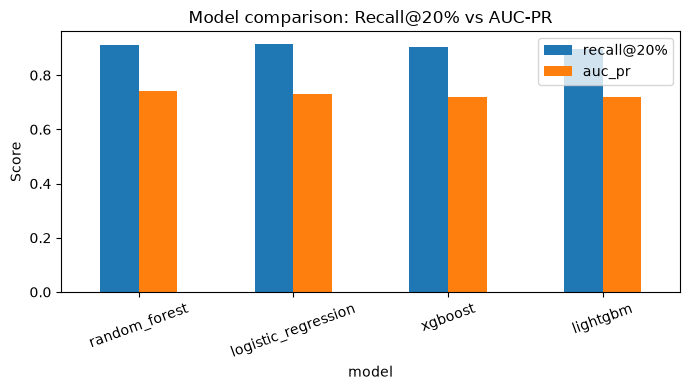

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
comparison.set_index('model')[['recall@20%','auc_pr']].plot(kind='bar', ax=ax)
plt.title('Model comparison: Recall@20% vs AUC-PR')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Calibrated metrics (selected model)

In [4]:
cal = eval_report['calibrated_metrics']
pd.Series(cal).to_frame('value')

,value
auc_roc,0.945841
auc_pr,0.714696
gini,0.891682
ks_statistic,0.764478
brier_score,0.029918
threshold_used,0.340000
precision,0.711765
recall,0.662409
f1_score,0.686200
recall_at_top10pct,0.779197


## Calibration curve

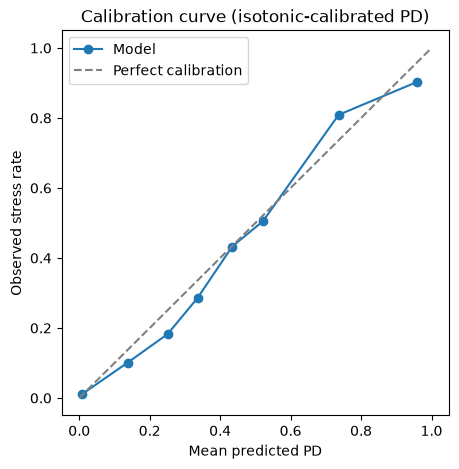

In [5]:
calib_curve = pd.DataFrame(eval_report['calibration_curve'])
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(calib_curve['mean_predicted_pd'], calib_curve['observed_stress_rate'], marker='o', label='Model')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted PD'); ax.set_ylabel('Observed stress rate'); ax.legend()
plt.title('Calibration curve (isotonic-calibrated PD)')
plt.show()

## Confusion matrix (tuned F1 threshold)

In [6]:
cm = eval_report['confusion_matrix_calibrated']
pd.DataFrame(cm, index=['Actual Non-Stress','Actual Stress'], columns=['Predicted Non-Stress','Predicted Stress'])

,Predicted Non-Stress,Predicted Stress
Actual Non-Stress,7705,147
Actual Stress,185,363


**Disclaimer:** all metrics are computed on synthetic data and validate pipeline design logic, not real-world bank-grade performance. See `reports/prototype_validation_note.md`.

## Next step

Proceed to `04_shap_explainability.ipynb`.